<a href="https://colab.research.google.com/github/romeurf/DipRadar/blob/main/experiments/ml_v2/DipRadar_v2_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DipRadar v2 — Dual Regression Training

**Objectivo:** Substituir o classificador binário (WIN/LOSE) por dois modelos de regressão:
- `model_3m` → prevê `return_3m` (recuperação a 3 meses)
- `model_6m` → prevê `return_6m` (magnitude total a 6 meses)

O bot combina os dois: `score = 0.4 * pred_3m + 0.6 * pred_6m`

**Fluxo:**
1. Setup
2. Carregar dataset do repo
3. Preparar targets + split temporal
4. Treinar model_3m e model_6m
5. Avaliar (Spearman, Top-K return, comparação com v1)
6. Feature importance (3m vs 6m)
7. Optimizar pesos do score combinado
8. Guardar modelos + download

> ⚠️ **Anti-leakage:** features calculadas com dados até `alert_date`; targets só usam preços após `alert_date`.

## 1. Setup

In [12]:
!pip install -q xgboost lightgbm yfinance scipy pyarrow scikit-learn

In [13]:
import os

if os.path.exists('DipRadar'):
    print('A fazer pull...')
    !cd DipRadar && git pull -q
else:
    !git clone -q https://github.com/romeurf/DipRadar.git

os.chdir('DipRadar')
print('OK —', os.getcwd())

OK — /content/DipRadar/DipRadar/DipRadar/DipRadar


## 2. Carregar Dataset

In [14]:
import pandas as pd
import numpy as np
from pathlib import Path

df = pd.read_parquet('ml_training_merged.parquet')
df['alert_date'] = pd.to_datetime(df['alert_date'])
df = df.sort_values('alert_date').reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Período: {df["alert_date"].min().date()} → {df["alert_date"].max().date()}')
print()

# Cobertura dos targets
print('Cobertura dos targets de regressão:')
print(f'  return_3m: {df["return_3m"].notna().sum()} / {len(df)} amostras ({df["return_3m"].notna().mean():.1%})')
print(f'  return_6m: {df["return_6m"].notna().sum()} / {len(df)} amostras ({df["return_6m"].notna().mean():.1%})')
print()
print('Distribuição return_6m (RAW — antes de limpeza):')
print(df['return_6m'].describe().round(2))

Shape: (17368, 27)
Período: 2006-05-19 → 2026-01-13

Cobertura dos targets de regressão:
  return_3m: 17368 / 17368 amostras (100.0%)
  return_6m: 17363 / 17368 amostras (100.0%)

Distribuição return_6m (RAW — antes de limpeza):
count    17363.00
mean        27.82
std        891.32
min       -621.68
25%        -11.56
50%          6.27
75%         24.04
max      50799.99
Name: return_6m, dtype: float64


In [ ]:
# OPCIONAL: incluir alert_db.csv com alertas reais (obter via /exportdb no bot)
INCLUDE_ALERT_DB = False  # @param {type:'boolean'}

if INCLUDE_ALERT_DB:
    from google.colab import files
    print('Upload alert_db.csv:')
    uploaded = files.upload()
    for fname in uploaded:
        db = pd.read_csv(fname)
        date_col = 'date_iso' if 'date_iso' in db.columns else 'alert_date'
        sym_col  = 'ticker'   if 'ticker'   in db.columns else 'symbol'
        db = db.rename(columns={date_col: 'alert_date', sym_col: 'symbol'})
        db['alert_date'] = pd.to_datetime(db['alert_date'])
        db = db[db['return_6m'].notna() | db['return_3m'].notna()]
        common = [c for c in df.columns if c in db.columns]
        df_merged = pd.concat([df[common].assign(_s=0), db[common].assign(_s=1)], ignore_index=True)
        df_merged = df_merged.sort_values('_s').drop_duplicates(
            subset=['symbol','alert_date'], keep='last'
        ).drop(columns='_s').sort_values('alert_date').reset_index(drop=True)
        df = df_merged
        print(f'após merge: {len(df)} linhas')
else:
    print('A usar apenas ml_training_merged.parquet (INCLUDE_ALERT_DB=False)')

## 3. Preparar Targets + Split Temporal

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Winsorização por percentil p1/p99
# -----------------------------------------------------------------------
# PORQUÊ p1/p99 em vez de 3σ:
#   std=891% → corte 3σ ficava em ±2700%, inútil para dados com
#   outliers extremos (penny stocks, erros de dados).
#   Clip por percentil é robusto independentemente da distribuição.
# -----------------------------------------------------------------------
print('Winsorização dos targets (p1 / p99):')
for col in ['return_3m', 'return_6m']:
    p1  = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    n_clipped = ((df[col] < p1) | (df[col] > p99)).sum()
    df[col] = df[col].clip(lower=p1, upper=p99)
    print(f'  {col}: clipado para [{p1:.1f}%, {p99:.1f}%]  '
          f'| amostras afectadas: {n_clipped}  '
          f'| mean={df[col].mean():.1f}%  median={df[col].median():.1f}%')
print()

Winsorização dos targets (p1 / p99):
  return_3m: clipado para [-54.7%, 66.5%]  | amostras afectadas: 348  | mean=3.4%  median=3.8%
  return_6m: clipado para [-67.2%, 113.1%]  | amostras afectadas: 348  | mean=7.1%  median=6.3%



Features (16): ['macro_score', 'vix', 'spy_drawdown_5d', 'sector_drawdown_5d', 'fcf_yield', 'revenue_growth', 'gross_margin', 'de_ratio', 'pe_vs_fair', 'analyst_upside', 'quality_score', 'drop_pct_today', 'drawdown_52w', 'rsi_14', 'atr_ratio', 'volume_spike']

Amostras disponíveis:
  model_6m: 17363
  model_3m: 17368


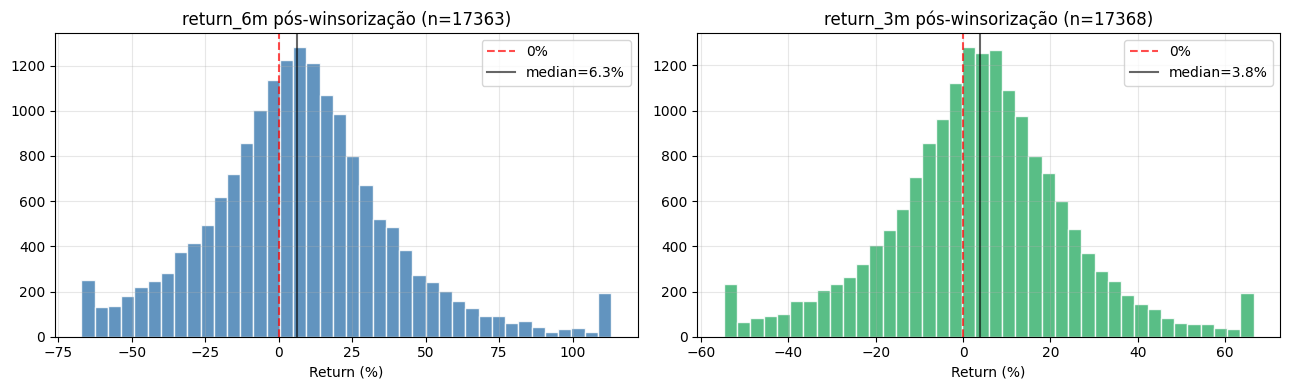

In [16]:
FEATURE_COLS = [
    'macro_score', 'vix', 'spy_drawdown_5d', 'sector_drawdown_5d',
    'fcf_yield', 'revenue_growth', 'gross_margin', 'de_ratio',
    'pe_vs_fair', 'analyst_upside', 'quality_score',
    'drop_pct_today', 'drawdown_52w', 'rsi_14', 'atr_ratio', 'volume_spike',
]
feat_cols = [c for c in FEATURE_COLS if c in df.columns]
print(f'Features ({len(feat_cols)}): {feat_cols}')

# Dataset para cada modelo (só amostras com target disponível)
df_6m = df[feat_cols + ['return_6m', 'alert_date']].dropna(subset=['return_6m'] + feat_cols[:4]).copy()
df_3m = df[feat_cols + ['return_3m', 'alert_date']].dropna(subset=['return_3m'] + feat_cols[:4]).copy()

# Imputar NaN nas features com mediana
for d in [df_6m, df_3m]:
    d[feat_cols] = d[feat_cols].fillna(d[feat_cols].median())

print(f'\nAmostras disponíveis:')
print(f'  model_6m: {len(df_6m)}')
print(f'  model_3m: {len(df_3m)}')

# Visualizar distribuição dos targets (pós-winsorização)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (col, color, df_t) in zip(axes, [
    ('return_6m', 'steelblue', df_6m),
    ('return_3m', 'mediumseagreen', df_3m),
]):
    ax.hist(df_t[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0,  color='red',   linestyle='--', alpha=0.7, label='0%')
    ax.axvline(df_t[col].median(), color='black', linestyle='-', alpha=0.6,
               label=f'median={df_t[col].median():.1f}%')
    ax.set_title(f'{col} pós-winsorização (n={len(df_t)})')
    ax.set_xlabel('Return (%)')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('target_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

In [17]:
# Split temporal 80/20 — NUNCA aleatório (leakage temporal)
def temporal_split(df_t, target_col, feat_cols, ratio=0.80):
    df_t = df_t.sort_values('alert_date').reset_index(drop=True)
    idx  = int(len(df_t) * ratio)
    tr, va = df_t.iloc[:idx], df_t.iloc[idx:]
    print(f'  Train: {len(tr):5d} | {tr["alert_date"].min().date()} → {tr["alert_date"].max().date()} | mean={tr[target_col].mean():.2f}%')
    print(f'  Val  : {len(va):5d} | {va["alert_date"].min().date()} → {va["alert_date"].max().date()} | mean={va[target_col].mean():.2f}%')
    return (tr[feat_cols].values, tr[target_col].values,
            va[feat_cols].values, va[target_col].values, va['alert_date'])

print('model_6m:')
X_train_6m, y_train_6m, X_val_6m, y_val_6m, dates_val_6m = temporal_split(df_6m, 'return_6m', feat_cols)
print()
print('model_3m:')
X_train_3m, y_train_3m, X_val_3m, y_val_3m, dates_val_3m = temporal_split(df_3m, 'return_3m', feat_cols)

model_6m:
  Train: 13890 | 2006-05-19 → 2020-05-13 | mean=5.14%
  Val  :  3473 | 2020-05-13 → 2025-10-28 | mean=15.08%

model_3m:
  Train: 13894 | 2006-05-19 → 2020-05-13 | mean=2.35%
  Val  :  3474 | 2020-05-13 → 2026-01-13 | mean=7.72%


## 4. Treinar model_6m e model_3m

In [18]:
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

XGB_PARAMS = dict(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,   # conservador — evita overfitting em dados financeiros
    reg_alpha=0.1,
    reg_lambda=2.0,
    objective='reg:squarederror',
    eval_metric='rmse',
    early_stopping_rounds=40,
    random_state=42,
    verbosity=0,
)

print('A treinar model_6m...')
model_6m = xgb.XGBRegressor(**XGB_PARAMS)
model_6m.fit(X_train_6m, y_train_6m,
             eval_set=[(X_val_6m, y_val_6m)], verbose=100)
print(f'  Best iter: {model_6m.best_iteration}')

print()
print('A treinar model_3m...')
model_3m = xgb.XGBRegressor(**XGB_PARAMS)
model_3m.fit(X_train_3m, y_train_3m,
             eval_set=[(X_val_3m, y_val_3m)], verbose=100)
print(f'  Best iter: {model_3m.best_iteration}')
print()
print('✅ Treino concluído.')

A treinar model_6m...
[0]	validation_0-rmse:27.42786
[100]	validation_0-rmse:26.44084
[165]	validation_0-rmse:26.36020
  Best iter: 125

A treinar model_3m...
[0]	validation_0-rmse:16.39945
[100]	validation_0-rmse:15.96520
[106]	validation_0-rmse:15.96120
  Best iter: 66

✅ Treino concluído.


## 5. Avaliar

In [19]:
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, r2_score

pred_6m = model_6m.predict(X_val_6m)
pred_3m = model_3m.predict(X_val_3m)

sp_6m, _ = spearmanr(pred_6m, y_val_6m)
sp_3m, _ = spearmanr(pred_3m, y_val_3m)

mae_6m = mean_absolute_error(y_val_6m, pred_6m)
mae_3m = mean_absolute_error(y_val_3m, pred_3m)

r2_6m = r2_score(y_val_6m, pred_6m)
r2_3m = r2_score(y_val_3m, pred_3m)

print('=' * 52)
print(f'           Spearman    MAE      R²')
print('-' * 52)
print(f'  model_6m   {sp_6m:+.4f}   {mae_6m:5.2f}%   {r2_6m:+.4f}')
print(f'  model_3m   {sp_3m:+.4f}   {mae_3m:5.2f}%   {r2_3m:+.4f}')
print('=' * 52)
print()
print('Interpretação:')
print(f'  Spearman 6m > 0.10 ? {"✅" if sp_6m > 0.10 else "⚠️"} ({sp_6m:.4f})  # mínimo util')
print(f'  Spearman 6m > 0.20 ? {"✅" if sp_6m > 0.20 else "❌"} ({sp_6m:.4f})  # bom')
print(f'  Spearman 3m > 0.10 ? {"✅" if sp_3m > 0.10 else "⚠️"} ({sp_3m:.4f})')

           Spearman    MAE      R²
----------------------------------------------------
  model_6m   +0.2457   19.41%   -0.0552
  model_3m   +0.1709   12.08%   -0.0571

Interpretação:
  Spearman 6m > 0.10 ? ✅ (0.2457)  # mínimo util
  Spearman 6m > 0.20 ? ✅ (0.2457)  # bom
  Spearman 3m > 0.10 ? ✅ (0.1709)


In [20]:
# Top-K mean return: ordena por score previsto, qual o retorno real médio no top K%?
# Este é o métrico mais relevante para o bot — importa ordenar bem, não o valor absoluto
import pandas as pd

print('Top-K Mean Return (model_6m):')
print(f'  Baseline (todos): {y_val_6m.mean():.2f}%')
print()

val_df = pd.DataFrame({'pred': pred_6m, 'real': y_val_6m}).sort_values('pred', ascending=False)
baseline = val_df['real'].mean()

for k in [0.05, 0.10, 0.20, 0.30]:
    n   = max(1, int(len(val_df) * k))
    top = val_df.head(n)['real'].mean()
    bot = val_df.tail(n)['real'].mean()
    lift = top / baseline if baseline != 0 else float('inf')
    ok = '✅' if top > baseline else '❌'
    print(f'  Top {k:.0%} (n={n:3d}): mean_return={top:+.2f}%  vs baseline={baseline:+.2f}%  lift={lift:.2f}x  {ok}')
print()
print('Bottom-K (pior score → deve ter menor retorno real):')
for k in [0.10, 0.20]:
    n   = max(1, int(len(val_df) * k))
    bot = val_df.tail(n)['real'].mean()
    ok  = '✅' if bot < baseline else '❌'
    print(f'  Bot {k:.0%} (n={n:3d}): mean_return={bot:+.2f}%  {ok}')

Top-K Mean Return (model_6m):
  Baseline (todos): 15.08%

  Top 5% (n=173): mean_return=+33.95%  vs baseline=+15.08%  lift=2.25x  ✅
  Top 10% (n=347): mean_return=+29.67%  vs baseline=+15.08%  lift=1.97x  ✅
  Top 20% (n=694): mean_return=+26.93%  vs baseline=+15.08%  lift=1.79x  ✅
  Top 30% (n=1041): mean_return=+25.04%  vs baseline=+15.08%  lift=1.66x  ✅

Bottom-K (pior score → deve ter menor retorno real):
  Bot 10% (n=347): mean_return=+12.92%  ✅
  Bot 20% (n=694): mean_return=+11.02%  ✅


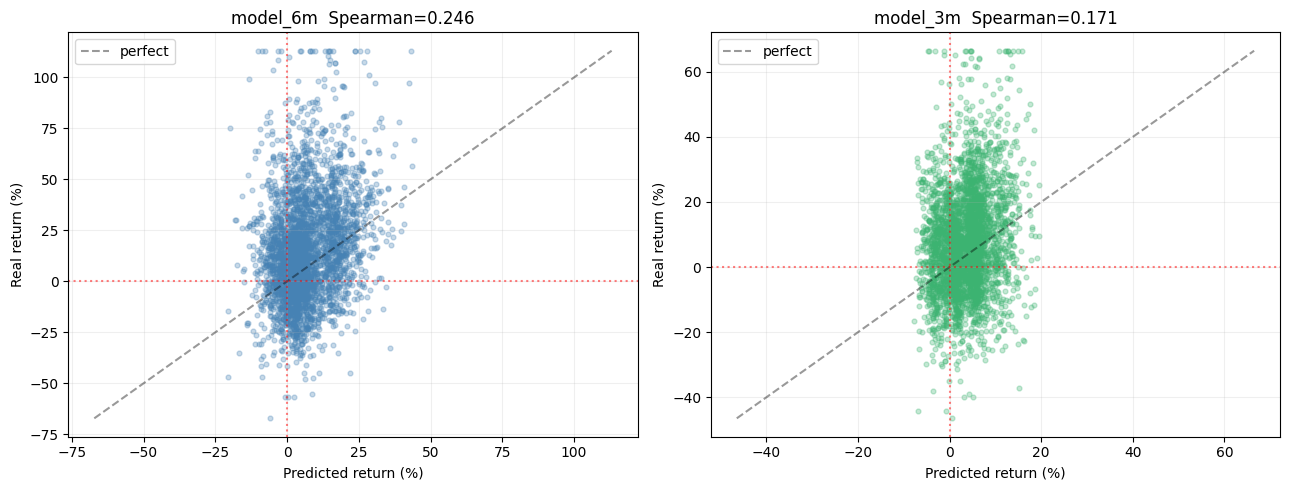

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (pred, real, title, color) in zip(axes, [
    (pred_6m, y_val_6m, f'model_6m  Spearman={sp_6m:.3f}', 'steelblue'),
    (pred_3m, y_val_3m, f'model_3m  Spearman={sp_3m:.3f}', 'mediumseagreen'),
]):
    ax.scatter(pred, real, alpha=0.3, s=12, color=color)
    lims = [min(pred.min(), real.min()), max(pred.max(), real.max())]
    ax.plot(lims, lims, 'k--', alpha=0.4, label='perfect')
    ax.axhline(0, color='red', linestyle=':', alpha=0.5)
    ax.axvline(0, color='red', linestyle=':', alpha=0.5)
    ax.set_xlabel('Predicted return (%)')
    ax.set_ylabel('Real return (%)')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('scatter_pred_vs_real.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Feature Importance (3m vs 6m)

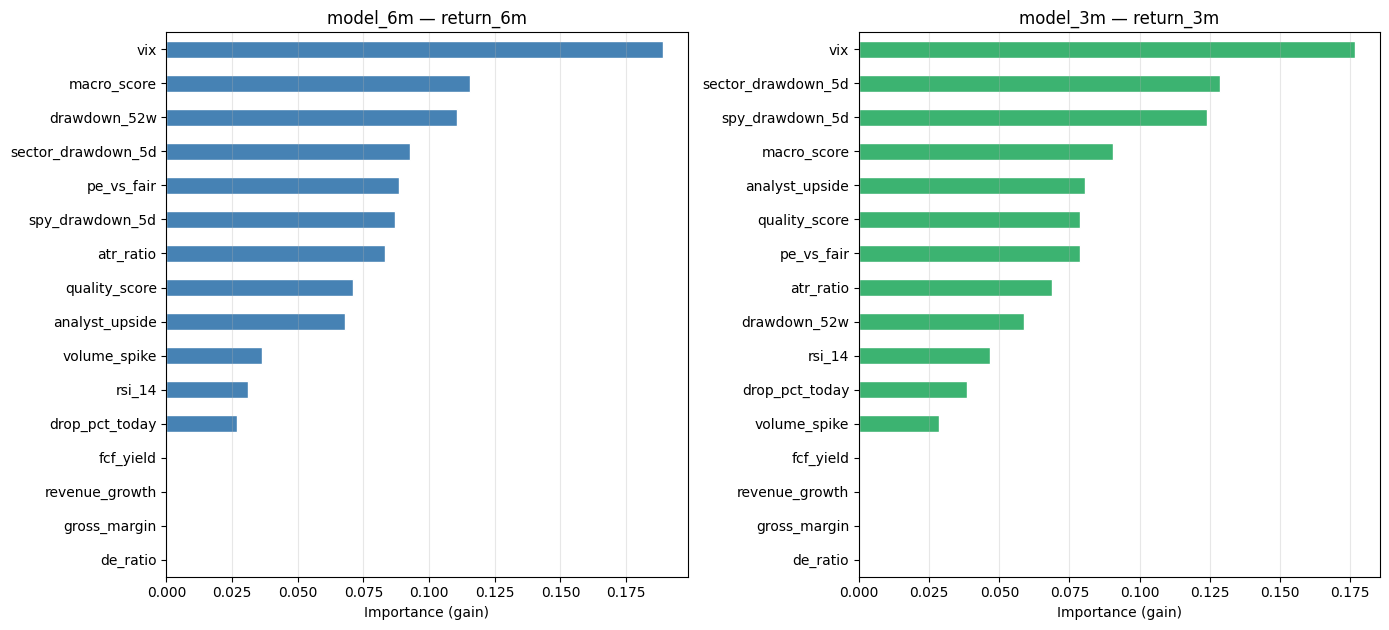

Feature importance comparada (6m vs 3m):
                        6m      3m
vix                 0.1890  0.1768
macro_score         0.1156  0.0905
drawdown_52w        0.1106  0.0589
sector_drawdown_5d  0.0928  0.1287
pe_vs_fair          0.0884  0.0787
spy_drawdown_5d     0.0872  0.1240
atr_ratio           0.0833  0.0689
quality_score       0.0709  0.0789
analyst_upside      0.0678  0.0806
volume_spike        0.0365  0.0286
rsi_14              0.0310  0.0468
drop_pct_today      0.0270  0.0386
gross_margin        0.0000  0.0000
fcf_yield           0.0000  0.0000
de_ratio            0.0000  0.0000
revenue_growth      0.0000  0.0000


In [22]:
import matplotlib.pyplot as plt
import pandas as pd

imp_6m = pd.Series(model_6m.feature_importances_, index=feat_cols).sort_values()
imp_3m = pd.Series(model_3m.feature_importances_, index=feat_cols).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(feat_cols) * 0.4)))

imp_6m.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('model_6m — return_6m')
axes[0].set_xlabel('Importance (gain)')
axes[0].grid(axis='x', alpha=0.3)

imp_3m.plot(kind='barh', ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('model_3m — return_3m')
axes[1].set_xlabel('Importance (gain)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance_v2.png', dpi=120, bbox_inches='tight')
plt.show()

# Comparação lado a lado
comp = pd.DataFrame({'6m': imp_6m, '3m': imp_3m}).sort_values('6m', ascending=False)
print('Feature importance comparada (6m vs 3m):')
print(comp.round(4).to_string())

## 7. Optimizar Pesos do Score Combinado

Melhor combinação encontrada:
  w_3m=0.60  w_6m=0.40  Spearman=0.2540



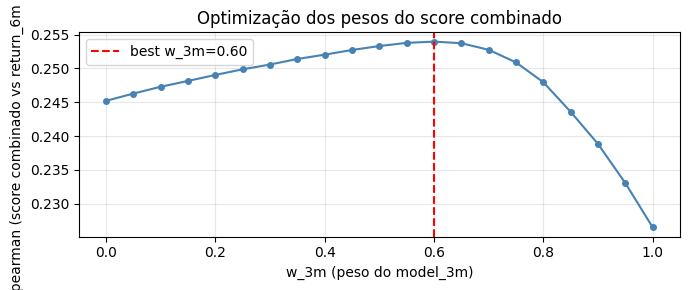


Pesos finais: score = 0.60 * pred_3m + 0.40 * pred_6m


In [23]:
# Encontrar os pesos w_3m / w_6m que maximizam o Spearman do score combinado
# Nota: só funciona para amostras que têm AMBOS os targets disponíveis
import numpy as np
from scipy.stats import spearmanr

# Amostras em comum entre os dois val sets
df_val_6m_full = df_6m.iloc[int(len(df_6m)*0.8):].copy()
df_val_3m_full = df_3m.iloc[int(len(df_3m)*0.8):].copy()

common_idx = df_val_6m_full.index.intersection(df_val_3m_full.index)

if len(common_idx) < 50:
    print(f'⚠️  Só {len(common_idx)} amostras em comum — a usar pesos fixos 0.4/0.6')
    best_w3, best_w6 = 0.4, 0.6
else:
    p6 = model_6m.predict(df_val_6m_full.loc[common_idx, feat_cols].values)
    p3 = model_3m.predict(df_val_3m_full.loc[common_idx, feat_cols].values)
    real_6m_common = df_val_6m_full.loc[common_idx, 'return_6m'].values

    best_sp, best_w3, best_w6 = -np.inf, 0.4, 0.6
    results = []
    for w3 in np.arange(0.0, 1.05, 0.05):
        w6 = round(1.0 - w3, 2)
        combined = w3 * p3 + w6 * p6
        sp, _ = spearmanr(combined, real_6m_common)
        results.append((w3, w6, sp))
        if sp > best_sp:
            best_sp, best_w3, best_w6 = sp, w3, w6

    print(f'Melhor combinação encontrada:')
    print(f'  w_3m={best_w3:.2f}  w_6m={best_w6:.2f}  Spearman={best_sp:.4f}')
    print()

    # Plot Spearman vs w_3m
    import matplotlib.pyplot as plt
    ws3, ws6, sps = zip(*results)
    plt.figure(figsize=(7, 3))
    plt.plot(ws3, sps, marker='o', color='steelblue', markersize=4)
    plt.axvline(best_w3, color='red', linestyle='--', label=f'best w_3m={best_w3:.2f}')
    plt.xlabel('w_3m (peso do model_3m)')
    plt.ylabel('Spearman (score combinado vs return_6m real)')
    plt.title('Optimização dos pesos do score combinado')
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('weight_optimization.png', dpi=120, bbox_inches='tight')
    plt.show()

print(f'\nPesos finais: score = {best_w3:.2f} * pred_3m + {best_w6:.2f} * pred_6m')

## 8. Guardar Modelos + Download

In [ ]:
import pickle, json
from pathlib import Path

# Critério de promoção: Spearman_6m > 0.10 (mínimo útil)
gating_ok = sp_6m > 0.10

print('Critérios de promoção:')
print(f'  Spearman_6m > 0.10 : {"✅ PASS" if sp_6m > 0.10 else "❌ FAIL"} ({sp_6m:.4f})')
print(f'  Top-10% > baseline : ver output da Secção 5')
print()

output_dir = Path('experiments/ml_v2')
output_dir.mkdir(parents=True, exist_ok=True)

# Bundle com ambos os modelos + metadados
bundle = {
    'model_6m':      model_6m,
    'model_3m':      model_3m,
    'feature_cols':  feat_cols,
    'w_3m':          float(best_w3),
    'w_6m':          float(best_w6),
    'spearman_6m':   float(sp_6m),
    'spearman_3m':   float(sp_3m),
    'mae_6m':        float(mae_6m),
    'mae_3m':        float(mae_3m),
    'n_train_6m':    len(X_train_6m),
    'n_train_3m':    len(X_train_3m),
    'n_val_6m':      len(X_val_6m),
    'gating_ok':     gating_ok,
    'train_date':    str(pd.Timestamp.now().date()),
}

pkl_path    = output_dir / 'dip_model_v2_candidate.pkl'
report_path = output_dir / 'eval_report_v2.json'

with open(pkl_path, 'wb') as f:
    pickle.dump(bundle, f)

report = {k: v for k, v in bundle.items() if k not in ('model_6m', 'model_3m')}
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2, default=str)

print(f'Guardado: {pkl_path}  ({pkl_path.stat().st_size / 1e6:.1f} MB)')
print(f'Guardado: {report_path}')
print()
if gating_ok:
    print('✅ Modelo pronto para shadow mode!')
else:
    print('⚠️  Spearman abaixo do mínimo — rever features ou hiperparâmetros.')

In [ ]:
from google.colab import files

for f in [pkl_path, report_path,
          Path('target_distributions.png'),
          Path('scatter_pred_vs_real.png'),
          Path('feature_importance_v2.png'),
          Path('weight_optimization.png')]:
    if f.exists():
        files.download(str(f))
        print(f'Download: {f.name}')
    else:
        print(f'(não encontrado: {f.name})')

## ✅ Próximos Passos

Se `gating_ok = True` (Spearman_6m > 0.10):

1. **Commit** do `dip_model_v2_candidate.pkl` para `experiments/ml_v2/`
2. **Shadow mode** no `ml_predictor.py`:
   ```python
   # Carrega v2 em paralelo; não altera alertas, só loga os scores
   score_v2 = w_3m * model_3m.predict(X) + w_6m * model_6m.predict(X)
   log.info(f'[shadow] {symbol} score_v2={score_v2:.2f}%')
   ```
3. Após 2–4 semanas comparar scores v1 vs v2 nos alertas reais
4. Só então substituir em produção

**O retreino mensal automático no Railway incorpora o `alert_db.csv` — não precisas de fazer nada para isso.**